# Responder Analysis: Who Benefits Most from Enhancement?

Exploratory notebook investigating whether patients cluster into distinct
response groups based on CNR improvement from Baseline to Enhanced reconstruction.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import Patch
from scipy import stats
from sklearn.mixture import GaussianMixture

NOTEBOOK_DIR = Path.home() / "vascular-superenhancement-4d-flow" / "notebooks" / "analysis" / "VSE_quantitative_analysis"
CSV_PATH = NOTEBOOK_DIR / "consolidated.csv"

COLORS = {"normal": "#5B8EC9", "vse": "#E8855E"}
LABELS = {"normal": "Baseline", "vse": "Enhanced"}
REGION_LABELS = {"Ao": "Aorta", "PA": "Pulmonary Artery", "IVS": "Interventricular Septum", "Air": "Air"}

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.dpi": 150,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.grid": True,
    "axes.grid.axis": "y",
    "grid.alpha": 0.3,
    "grid.linewidth": 0.5,
})

data = pd.read_csv(CSV_PATH)
data["snr"] = data["mean"] / data["std"]
print(f"{len(data)} rows | {data['patient'].nunique()} patients")

2360 rows | 15 patients


## 1. Compute per-patient CNR_myo response

For each patient and vessel region (Ao, PA separately), compute the time-averaged
CNR\_myo under both reconstructions, then calculate the change.

In [2]:
cnr_regions = ["Ao", "PA"]
patients = sorted(data["patient"].unique())

# Per-timepoint CNR_myo (matches 02_analysis.ipynb methodology)
vessels = data[data["region"].isin(cnr_regions)].copy()
ivs = data[data["region"] == "IVS"][["patient", "reconstruction", "timepoint", "mean", "std"]].rename(
    columns={"mean": "ivs_mean", "std": "ivs_std"})
cnr_myo_data = vessels.merge(ivs, on=["patient", "reconstruction", "timepoint"], how="inner")
cnr_myo_data["cnr_myo"] = (cnr_myo_data["mean"] - cnr_myo_data["ivs_mean"]) / cnr_myo_data["ivs_std"]

cnr_avg = (
    cnr_myo_data.groupby(["patient", "region", "reconstruction"])["cnr_myo"]
    .mean().reset_index().rename(columns={"cnr_myo": "cnr_mean"})
)

cnr_pivot = cnr_avg.pivot_table(index=["patient", "region"], columns="reconstruction", values="cnr_mean")
cnr_pivot["delta"] = cnr_pivot["vse"] - cnr_pivot["normal"]

# Per-patient, per-region response
response = cnr_pivot[["delta"]].reset_index().pivot_table(index="patient", columns="region", values="delta")
response.columns = [f"delta_{r}" for r in response.columns]

for region in cnr_regions:
    col = f"delta_{region}"
    print(f"--- {region} ---")
    display(response[[col]].sort_values(col, ascending=False).round(2))
    print()

--- Ao ---


,delta_Ao
patient,
Golotag,21.86
Diequipi,16.21
Bomatog,12.23
Diepami,8.53
Dublafer,7.55
Diecudey,6.55
Balboloop,6.53
Gueshifa,4.12
Grequafie,4.12



--- PA ---


,delta_PA
patient,
Golotag,24.57
Diepami,20.87
Diequipi,14.91
Diecudey,12.34
Bomatog,9.80
Dujomal,7.67
Balboloop,6.75
Dublafer,5.98
Gueshifa,2.08


## 2. Waterfall plot of response magnitude

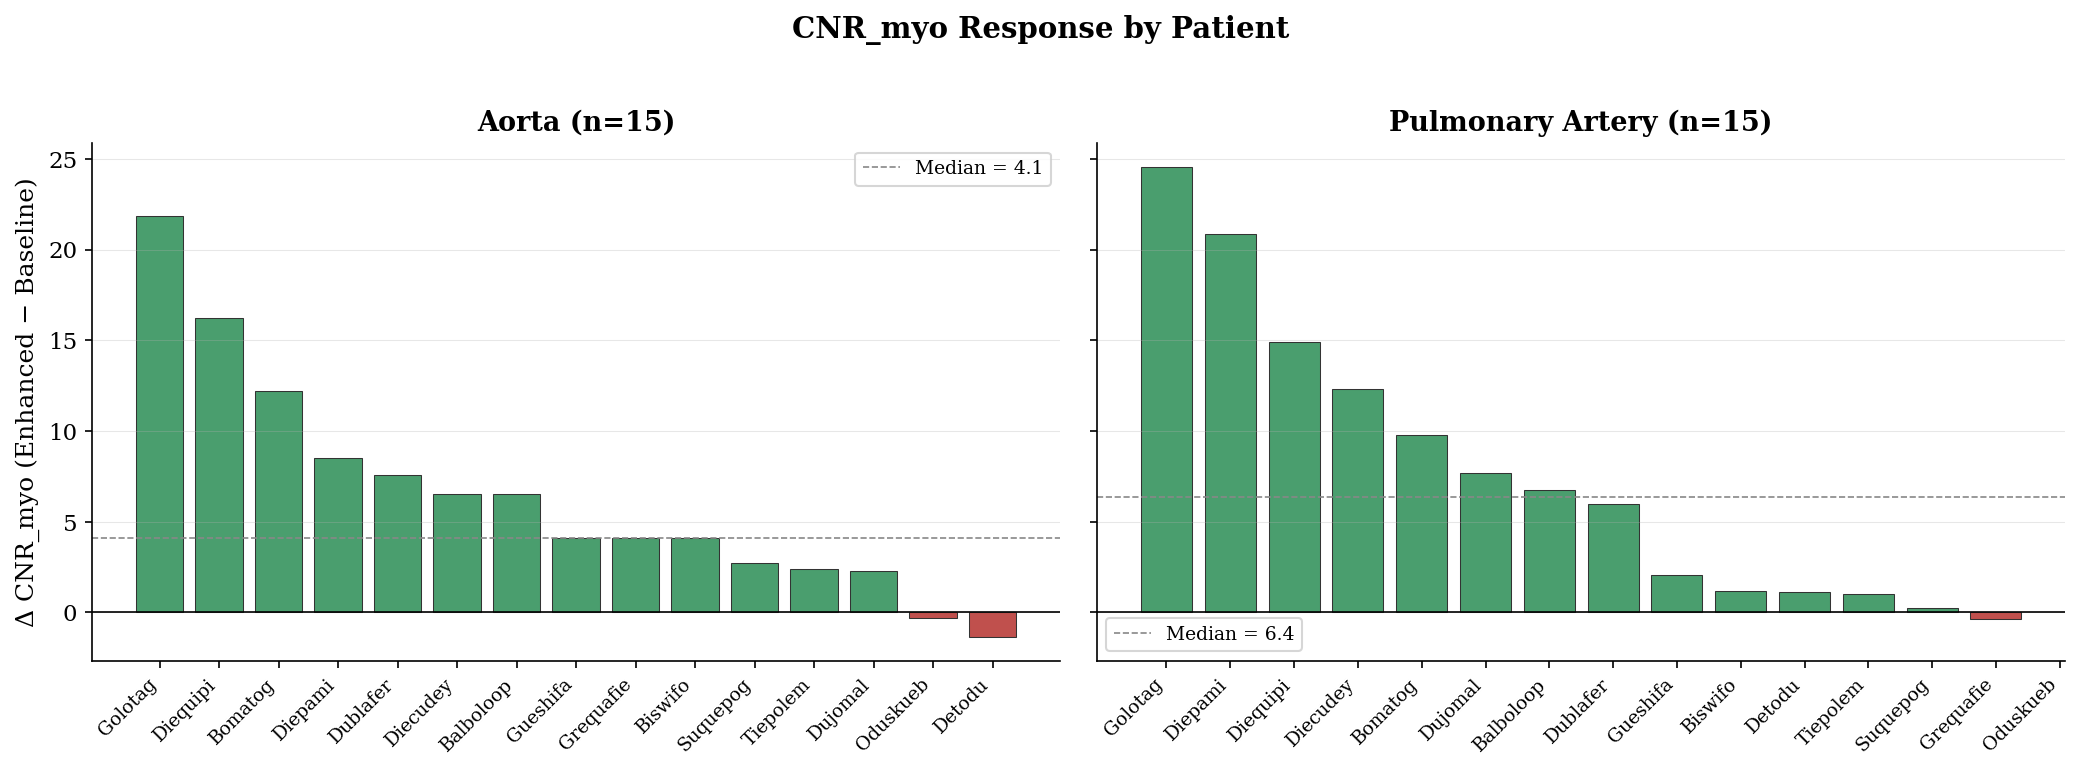

In [3]:
fig, axes = plt.subplots(1, len(cnr_regions), figsize=(7 * len(cnr_regions), 5), sharey=True)

for ax, region in zip(axes, cnr_regions):
    col = f"delta_{region}"
    sorted_resp = response.sort_values(col, ascending=False)
    colors = ["#4a9e6e" if v >= 0 else "#c0504d" for v in sorted_resp[col]]

    ax.bar(range(len(sorted_resp)), sorted_resp[col], color=colors, edgecolor="#333", linewidth=0.5)
    ax.set_xticks(range(len(sorted_resp)))
    ax.set_xticklabels(sorted_resp.index, rotation=45, ha="right", fontsize=9)
    ax.set_title(f"{REGION_LABELS[region]} (n={len(sorted_resp)})", fontweight="bold")
    ax.axhline(0, color="black", linewidth=0.8)
    med = sorted_resp[col].median()
    ax.axhline(med, color="#888", linestyle="--", linewidth=0.8,
               label=f"Median = {med:.1f}")
    ax.legend(fontsize=9)

axes[0].set_ylabel("Δ CNR_myo (Enhanced − Baseline)")
fig.suptitle("CNR_myo Response by Patient", fontsize=14, fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()

## 3. Natural gap analysis

Sort patients by response magnitude and find the largest gap between
consecutive patients — a simple heuristic for identifying a natural split.

In [4]:
for region in cnr_regions:
    col = f"delta_{region}"
    sorted_vals = response.sort_values(col, ascending=False)
    deltas = sorted_vals[col].values
    gaps = -np.diff(deltas)
    largest_gap_idx = np.argmax(gaps)

    high = sorted_vals.iloc[:largest_gap_idx + 1]
    low = sorted_vals.iloc[largest_gap_idx + 1:]

    print(f"--- {region} ---")
    print(f"Largest gap between rank {largest_gap_idx+1} ({high.index[-1]}, Δ={deltas[largest_gap_idx]:.2f}) "
          f"and rank {largest_gap_idx+2} ({low.index[0]}, Δ={deltas[largest_gap_idx+1]:.2f}): "
          f"gap = {gaps[largest_gap_idx]:.2f}")
    print(f"  High responders  ({len(high)}): {', '.join(high.index)} — mean Δ = {high[col].mean():.2f}")
    print(f"  Low/mod responders ({len(low)}): {', '.join(low.index)} — mean Δ = {low[col].mean():.2f}")
    print()

--- Ao ---
Largest gap between rank 1 (Golotag, Δ=21.86) and rank 2 (Diequipi, Δ=16.21): gap = 5.65
  High responders  (1): Golotag — mean Δ = 21.86
  Low/mod responders (14): Diequipi, Bomatog, Diepami, Dublafer, Diecudey, Balboloop, Gueshifa, Grequafie, Biswifo, Suquepog, Tiepolem, Dujomal, Oduskueb, Detodu — mean Δ = 5.41

--- PA ---
Largest gap between rank 14 (Grequafie, Δ=-0.33) and rank 15 (Oduskueb, Δ=nan): gap = nan
  High responders  (14): Golotag, Diepami, Diequipi, Diecudey, Bomatog, Dujomal, Balboloop, Dublafer, Gueshifa, Biswifo, Detodu, Tiepolem, Suquepog, Grequafie — mean Δ = 7.73
  Low/mod responders (1): Oduskueb — mean Δ = nan



## 4. Gaussian Mixture Model (k=2 vs k=1)

Fit 1- and 2-component Gaussian mixtures to the response distribution.
Compare BIC — lower BIC favors that model.

In [5]:
gmm_results = {}
for region in cnr_regions:
    col = f"delta_{region}"
    X = response[[col]].dropna().values

    gmm1 = GaussianMixture(n_components=1, random_state=42).fit(X)
    gmm2 = GaussianMixture(n_components=2, random_state=42).fit(X)

    print(f"--- {region} ---")
    print(f"  1-component BIC: {gmm1.bic(X):.1f}")
    print(f"  2-component BIC: {gmm2.bic(X):.1f}")
    print(f"  → {'2 components favored' if gmm2.bic(X) < gmm1.bic(X) else '1 component favored (no evidence of bimodality)'}")

    gmm_labels = gmm2.predict(X)
    means = gmm2.means_.flatten()
    group_order = np.argsort(means)[::-1]
    print(f"  Group means: {means[group_order[0]]:.2f} (high), {means[group_order[1]]:.2f} (low)")
    valid_idx = response[[col]].dropna().index
    for gi, gname in zip(group_order, ["High", "Low/Moderate"]):
        members = valid_idx[gmm_labels == gi].tolist()
        print(f"  {gname}: {', '.join(members)}")
    gmm_results[region] = (gmm2, gmm_labels, valid_idx)
    print()

--- Ao ---
  1-component BIC: 101.8
  2-component BIC: 104.2
  → 1 component favored (no evidence of bimodality)
  Group means: 16.56 (high), 4.03 (low)
  High: Bomatog, Diequipi, Golotag
  Low/Moderate: Balboloop, Biswifo, Detodu, Diecudey, Diepami, Dublafer, Dujomal, Grequafie, Gueshifa, Oduskueb, Suquepog, Tiepolem

--- PA ---
  1-component BIC: 102.0
  2-component BIC: 97.6
  → 2 components favored
  Group means: 12.25 (high), 0.88 (low)
  High: Balboloop, Bomatog, Diecudey, Diepami, Diequipi, Dublafer, Dujomal, Golotag
  Low/Moderate: Biswifo, Detodu, Grequafie, Gueshifa, Suquepog, Tiepolem



## 5. Histogram with GMM overlay

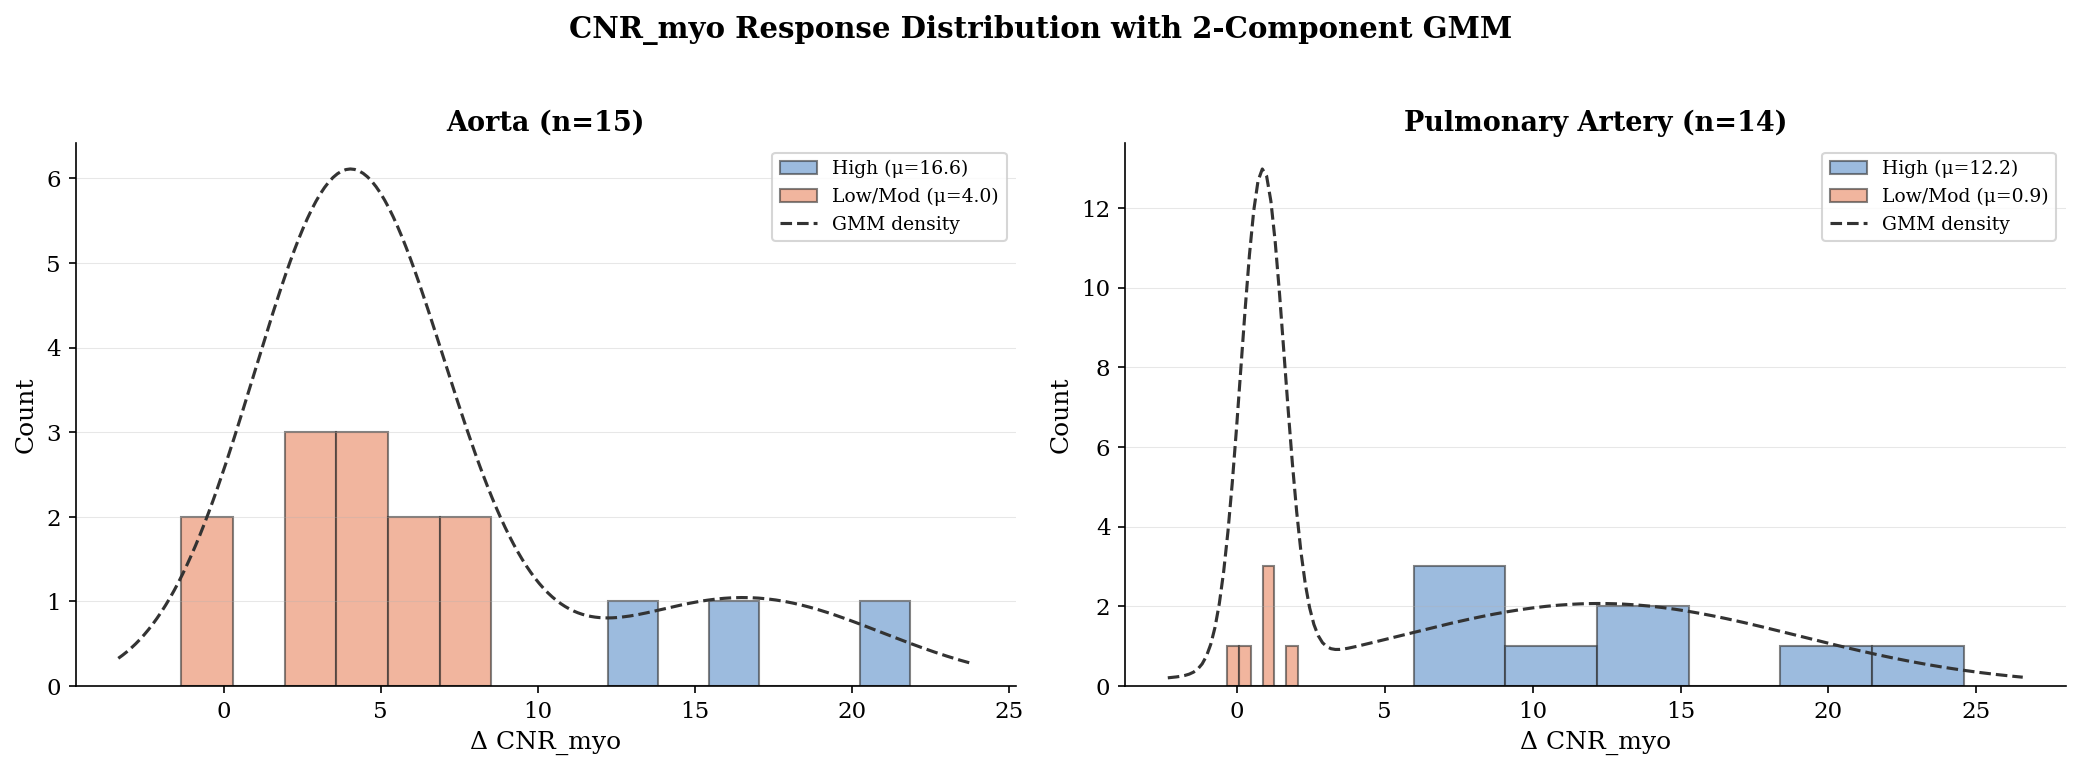

In [6]:
group_colors = ["#5B8EC9", "#E8855E"]

fig, axes = plt.subplots(1, len(cnr_regions), figsize=(7 * len(cnr_regions), 5))

for ax, region in zip(axes, cnr_regions):
    col = f"delta_{region}"
    gmm2, gmm_labels, valid_idx = gmm_results[region]
    X = response.loc[valid_idx, col].values.reshape(-1, 1)
    means = gmm2.means_.flatten()
    group_order = np.argsort(means)[::-1]

    ax.hist(X[gmm_labels == group_order[0]], bins=6, alpha=0.6, color=group_colors[0],
            edgecolor="#333", label=f"High (μ={means[group_order[0]]:.1f})")
    ax.hist(X[gmm_labels == group_order[1]], bins=6, alpha=0.6, color=group_colors[1],
            edgecolor="#333", label=f"Low/Mod (μ={means[group_order[1]]:.1f})")

    x_range = np.linspace(X.min() - 2, X.max() + 2, 200).reshape(-1, 1)
    log_prob = gmm2.score_samples(x_range)
    ax.plot(x_range, np.exp(log_prob) * len(X) * (X.max() - X.min()) / 6,
            color="#333", linewidth=1.5, linestyle="--", label="GMM density")

    ax.set_xlabel("Δ CNR_myo")
    ax.set_ylabel("Count")
    ax.set_title(f"{REGION_LABELS[region]} (n={len(X)})", fontweight="bold")
    ax.legend(fontsize=9)

fig.suptitle("CNR_myo Response Distribution with 2-Component GMM",
             fontsize=14, fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()

## 6. What predicts response?

Check whether baseline CNR, baseline SI, or baseline SNR correlate with
the magnitude of enhancement response.

In [7]:
baseline_features = []
for pt in patients:
    row = {"patient": pt}
    for region in ["Ao", "PA", "IVS", "Air"]:
        sub = data[(data["patient"] == pt) & (data["region"] == region) & (data["reconstruction"] == "normal")]
        if len(sub) > 0:
            row[f"{region}_mean_SI"] = sub["mean"].mean()
            row[f"{region}_std"] = sub["std"].mean()
            row[f"{region}_snr"] = sub["snr"].mean()
    baseline_features.append(row)

baseline_df = pd.DataFrame(baseline_features).set_index("patient")
combined = baseline_df.join(response)

predictors = [c for c in baseline_df.columns]

for region in cnr_regions:
    col = f"delta_{region}"
    print(f"--- {region} ---")
    print(f"{'Predictor':<22s}  {'r':>8s}  {'p':>8s}")
    print("-" * 42)
    for pred in predictors:
        valid = combined[[pred, col]].dropna()
        r, p = stats.pearsonr(valid[pred], valid[col])
        sig = "*" if p < 0.05 else ""
        print(f"{pred:<22s}  {r:+7.3f}{sig}  {p:8.4f}")
    print()

--- Ao ---
Predictor                      r         p
------------------------------------------
Ao_mean_SI               +0.430    0.1099
Ao_std                   +0.277    0.3172
Ao_snr                   -0.041    0.8859
PA_mean_SI               +0.312    0.2769
PA_std                   +0.288    0.3173
PA_snr                   -0.008    0.9797
IVS_mean_SI              +0.557*    0.0311
IVS_std                  +0.456    0.0878
IVS_snr                  +0.127    0.6519
Air_mean_SI              +0.239    0.3915
Air_std                  +0.091    0.7483
Air_snr                  +0.452    0.0907

--- PA ---
Predictor                      r         p
------------------------------------------
Ao_mean_SI               +0.522    0.0554
Ao_std                   +0.541*    0.0456
Ao_snr                   -0.363    0.2016
PA_mean_SI               +0.391    0.1672
PA_std                   +0.388    0.1700
PA_snr                   -0.096    0.7451
IVS_mean_SI              +0.546*    0.0436
IVS_

## 7. Scatter: baseline feature vs response

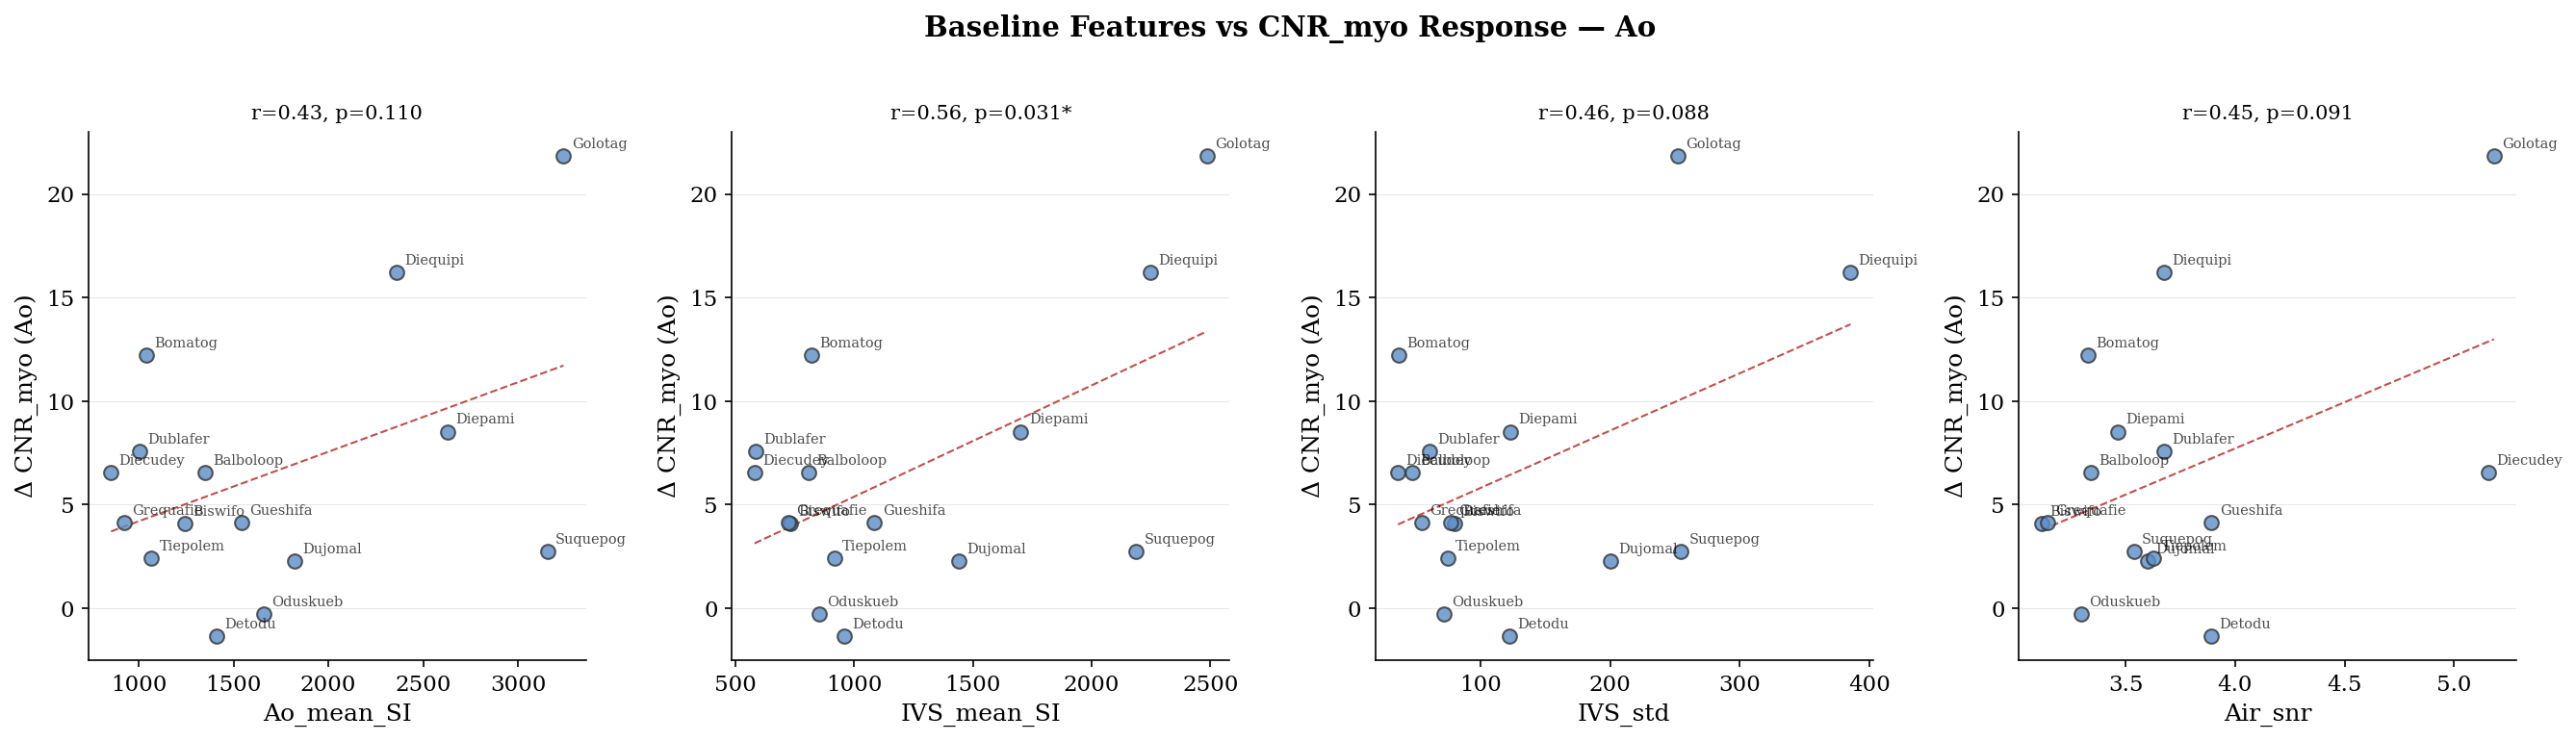

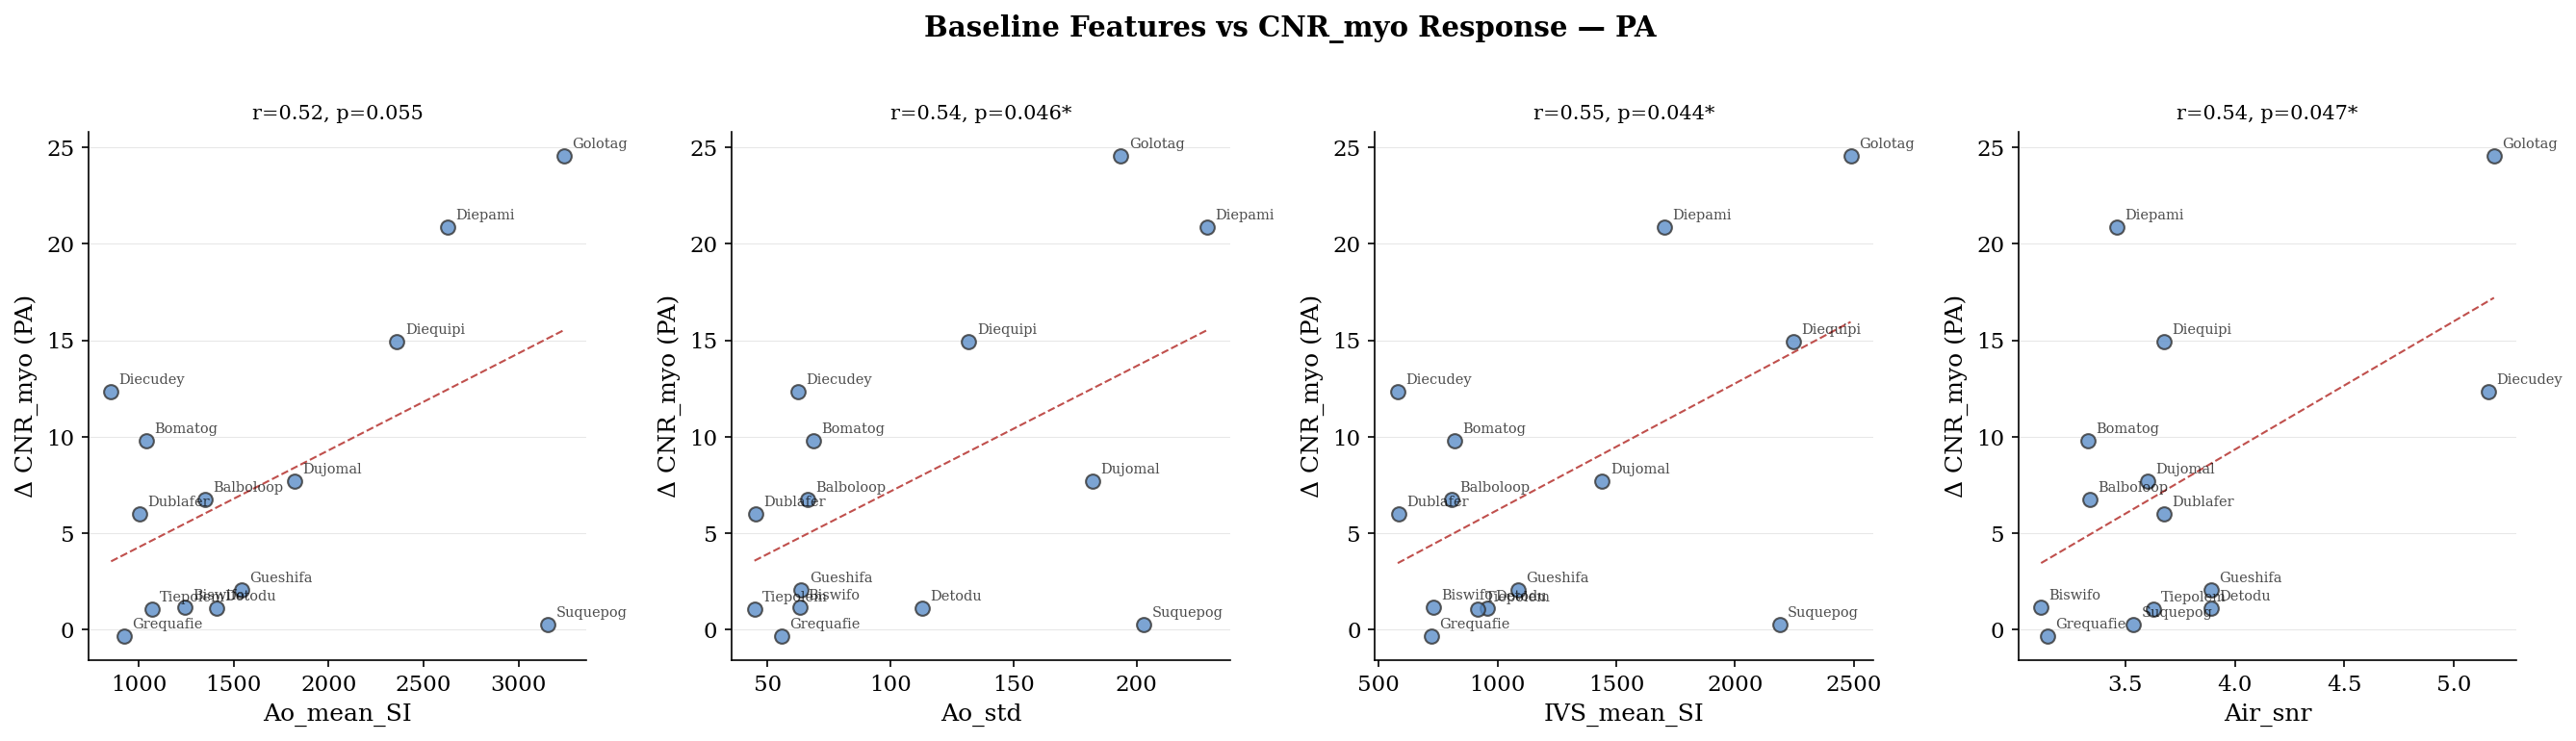

In [8]:
for region in cnr_regions:
    col = f"delta_{region}"

    interesting = []
    for pred in predictors:
        valid = combined[[pred, col]].dropna()
        _, p = stats.pearsonr(valid[pred], valid[col])
        if p < 0.15:
            interesting.append(pred)
    if not interesting:
        interesting = predictors[:4]

    n_plots = len(interesting)
    fig, axes = plt.subplots(1, n_plots, figsize=(4.5 * n_plots, 5), squeeze=False)

    for j, pred in enumerate(interesting):
        ax = axes[0, j]
        valid = combined[[pred, col]].dropna()
        r, p = stats.pearsonr(valid[pred], valid[col])

        ax.scatter(valid[pred], valid[col], c="#5B8EC9", edgecolors="#333",
                   s=50, alpha=0.8, zorder=3)
        for pt in valid.index:
            ax.annotate(pt, (valid.loc[pt, pred], valid.loc[pt, col]),
                        fontsize=7, alpha=0.7, xytext=(4, 4), textcoords="offset points")

        z = np.polyfit(valid[pred], valid[col], 1)
        xline = np.linspace(valid[pred].min(), valid[pred].max(), 50)
        ax.plot(xline, np.polyval(z, xline), "--", color="#c0504d", linewidth=1)

        ax.set_xlabel(pred)
        ax.set_ylabel(f"Δ CNR_myo ({region})")
        sig = "*" if p < 0.05 else ""
        ax.set_title(f"r={r:.2f}, p={p:.3f}{sig}", fontsize=10)

    fig.suptitle(f"Baseline Features vs CNR_myo Response — {region}",
                 fontsize=14, fontweight="bold", y=1.02)
    fig.tight_layout()
    plt.show()

## 8. Per-region breakdown: Ao vs PA response

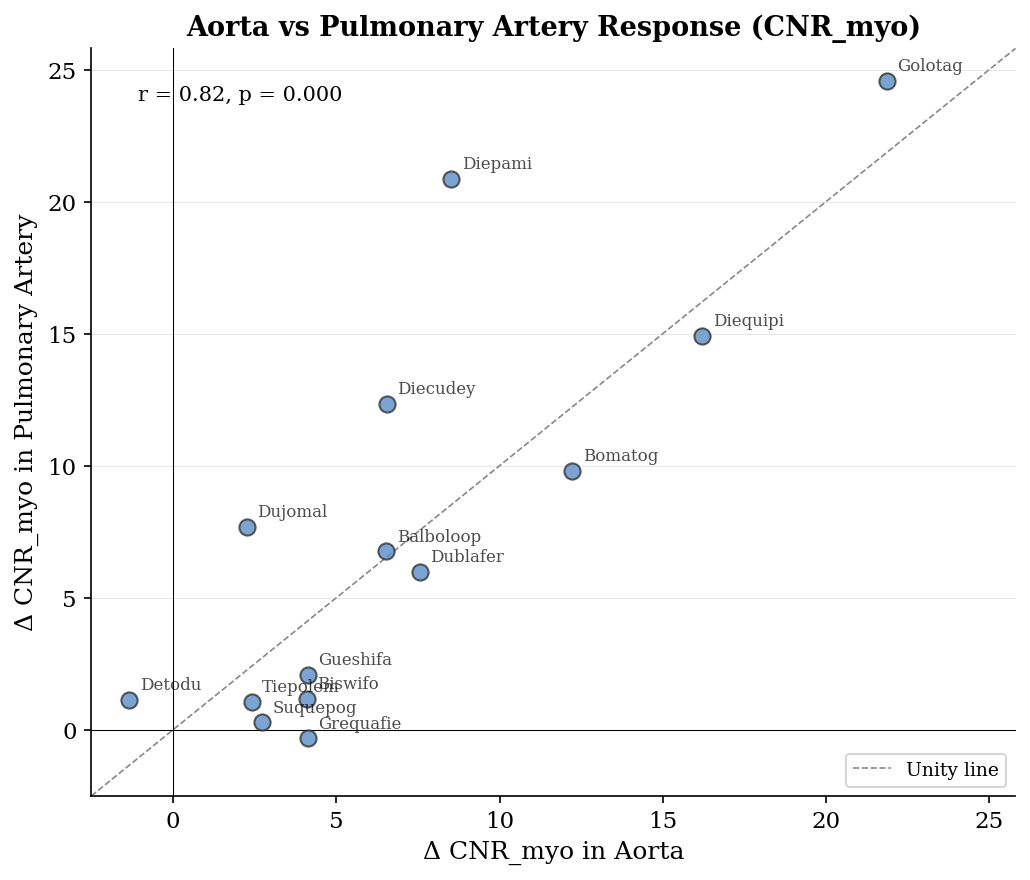

In [9]:
valid = response.dropna()

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(valid["delta_Ao"], valid["delta_PA"],
           c="#5B8EC9", edgecolors="#333", s=60, alpha=0.8, zorder=3)
for pt in valid.index:
    ax.annotate(pt, (valid.loc[pt, "delta_Ao"], valid.loc[pt, "delta_PA"]),
                fontsize=8, alpha=0.7, xytext=(5, 5), textcoords="offset points")

lims = [min(ax.get_xlim()[0], ax.get_ylim()[0]), max(ax.get_xlim()[1], ax.get_ylim()[1])]
ax.plot(lims, lims, "--", color="#888", linewidth=0.8, label="Unity line")
ax.axhline(0, color="black", linewidth=0.5)
ax.axvline(0, color="black", linewidth=0.5)
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel("Δ CNR_myo in Aorta")
ax.set_ylabel("Δ CNR_myo in Pulmonary Artery")
ax.set_title("Aorta vs Pulmonary Artery Response (CNR_myo)", fontweight="bold")
ax.legend(fontsize=9)

r, p = stats.pearsonr(valid["delta_Ao"], valid["delta_PA"])
ax.text(0.05, 0.95, f"r = {r:.2f}, p = {p:.3f}", transform=ax.transAxes,
        fontsize=10, va="top")

fig.tight_layout()
plt.show()